In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 1: Load CSV files

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nSentiment head:")
print(sentiment.head())

print("\nTrades head:")
print(trades.head())

Sentiment shape: (2644, 4)
Trades shape: (130534, 16)

Sentiment head:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades head:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-202

/tmp/ipykernel_7334/3835048958.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [4]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
print("Sentiment missing values:")
print(sentiment.isna().sum())

print("\nTrades missing values:")
print(trades.isna().sum())

Sentiment missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [7]:
print("Sentiment duplicate rows:", sentiment.duplicated().sum())
print("Trades duplicate rows:", trades.duplicated().sum())

Sentiment duplicate rows: 0
Trades duplicate rows: 0


In [10]:
# Step 3: convert timestamps to date

# Sentiment date (already looks standard, but we ensure datetime)
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

# Trades date from Timestamp IST, with dayfirst=True
trades["date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
).dt.date

# Quick check
print(sentiment[["timestamp", "date"]].head())
print(trades[["Timestamp IST", "date"]].head())

    timestamp        date
0  1517463000  2018-02-01
1  1517549400  2018-02-02
2  1517635800  2018-02-03
3  1517722200  2018-02-04
4  1517808600  2018-02-05
      Timestamp IST        date
0  02-12-2024 22:50  2024-12-02
1  02-12-2024 22:50  2024-12-02
2  02-12-2024 22:50  2024-12-02
3  02-12-2024 22:50  2024-12-02
4  02-12-2024 22:50  2024-12-02


In [11]:
# Step 4: daily aggregates per date

daily_trades = trades.groupby("date").agg(
    daily_pnl=("Closed PnL", "sum"),
    num_trades=("Trade ID", "count"),
    avg_size_usd=("Size USD", "mean"),
).reset_index()

print(daily_trades.head())

         date   daily_pnl  num_trades  avg_size_usd
0  2023-05-01    0.000000           3    159.000000
1  2023-12-05    0.000000           9   5556.203333
2  2023-12-14 -205.434737          11  10291.213636
3  2023-12-15  -24.632034           2   5304.975000
4  2023-12-16    0.000000           3   5116.256667


In [12]:
# Merge daily metrics with sentiment by date

daily = daily_trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print(daily.head())
print("\nSentiment value counts:")
print(daily["classification"].value_counts(dropna=False))

         date   daily_pnl  num_trades  avg_size_usd classification
0  2023-05-01    0.000000           3    159.000000          Greed
1  2023-12-05    0.000000           9   5556.203333  Extreme Greed
2  2023-12-14 -205.434737          11  10291.213636          Greed
3  2023-12-15  -24.632034           2   5304.975000          Greed
4  2023-12-16    0.000000           3   5116.256667          Greed

Sentiment value counts:
classification
Greed            193
Extreme Greed    114
Fear              90
Neutral           67
Extreme Fear      14
NaN                1
Name: count, dtype: int64


In [15]:
# Daily long/short counts based on Side column

daily_long_short = trades.groupby(["date", "Side"]).size().unstack(fill_value=0)

print(daily_long_short.head())

Side        BUY  SELL
date                 
2023-05-01    3     0
2023-12-05    7     2
2023-12-14    5     6
2023-12-15    2     0
2023-12-16    3     0


In [16]:
# Merge long/short counts into daily table

daily = daily.merge(
    daily_long_short,
    on="date",
    how="left"
)

print(daily.head())

         date   daily_pnl  num_trades  avg_size_usd classification  BUY  SELL
0  2023-05-01    0.000000           3    159.000000          Greed    3     0
1  2023-12-05    0.000000           9   5556.203333  Extreme Greed    7     2
2  2023-12-14 -205.434737          11  10291.213636          Greed    5     6
3  2023-12-15  -24.632034           2   5304.975000          Greed    2     0
4  2023-12-16    0.000000           3   5116.256667          Greed    3     0


In [17]:
print(daily.columns)

Index(['date', 'daily_pnl', 'num_trades', 'avg_size_usd', 'classification',
       'BUY', 'SELL'],
      dtype='object')


In [19]:
# Basic performance / behavior by sentiment classification

summary_by_sentiment = daily.groupby("classification").agg(
    mean_daily_pnl=("daily_pnl", "mean"),
    median_daily_pnl=("daily_pnl", "median"),
    mean_num_trades=("num_trades", "mean"),
    mean_avg_size_usd=("avg_size_usd", "mean"),
    mean_BUY=("BUY", "mean"),
    mean_SELL=("SELL", "mean")
)

print(summary_by_sentiment)

                mean_daily_pnl  median_daily_pnl  mean_num_trades  \
classification                                                      
Extreme Fear      40800.334296       8956.869289       629.500000   
Extreme Greed     16534.600692       2371.995694       207.903509   
Fear              29835.787187       2022.856798       413.366667   
Greed              6494.527883        625.561479       184.823834   
Neutral           18140.950660       1591.052029       375.208955   

                mean_avg_size_usd    mean_BUY   mean_SELL  
classification                                             
Extreme Fear          3954.049599  351.857143  277.642857  
Extreme Greed         5678.008767   94.929825  112.982456  
Fear                  6924.046210  206.511111  206.855556  
Greed                 6916.527318   94.632124   90.191710  
Neutral               7415.887784  198.208955  177.000000  


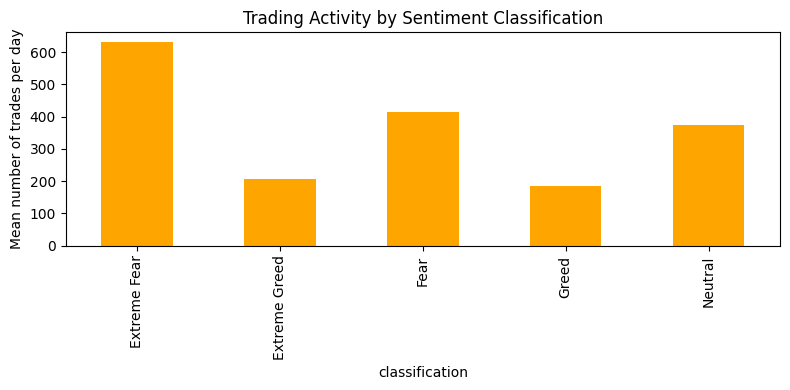

In [21]:
# Mean number of trades per day by sentiment

summary_by_sentiment["mean_num_trades"].plot(
    kind="bar",
    figsize=(8, 4),
    ylabel="Mean number of trades per day",
    title="Trading Activity by Sentiment Classification",
    color="orange"
)
plt.tight_layout()
plt.show()

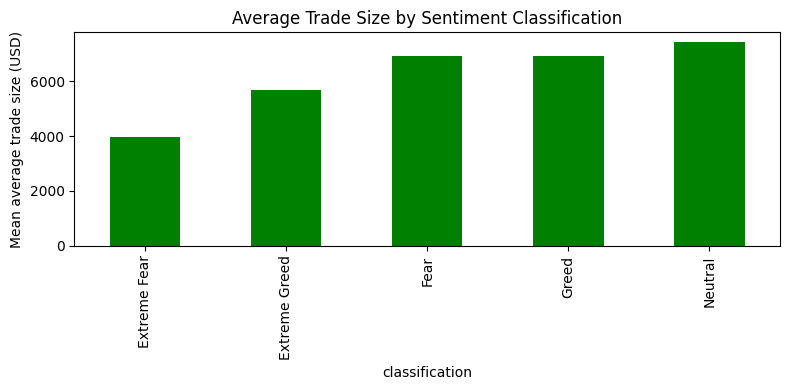

In [22]:
# Mean average trade size (USD) by sentiment

summary_by_sentiment["mean_avg_size_usd"].plot(
    kind="bar",
    figsize=(8, 4),
    ylabel="Mean average trade size (USD)",
    title="Average Trade Size by Sentiment Classification",
    color="green"
)
plt.tight_layout()
plt.show()

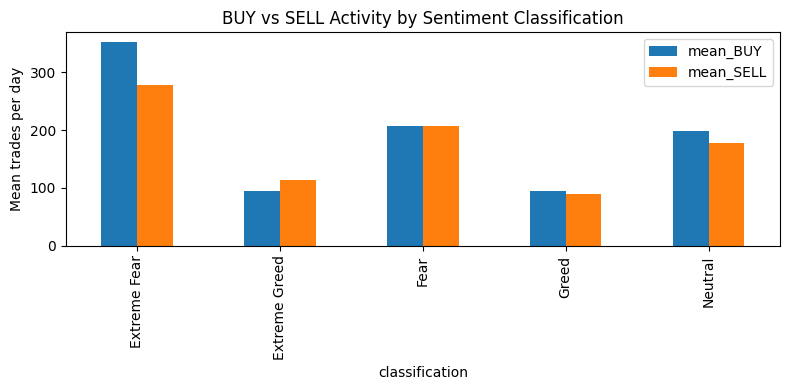

In [23]:
# BUY vs SELL mean counts per day by sentiment

summary_by_sentiment[["mean_BUY", "mean_SELL"]].plot(
    kind="bar",
    figsize=(8, 4),
    ylabel="Mean trades per day",
    title="BUY vs SELL Activity by Sentiment Classification"
)
plt.tight_layout()
plt.show()

In [24]:
# Per-account, per-day metrics

# Mark wins and losses at trade level
trades["is_win"] = trades["Closed PnL"] > 0
trades["is_loss"] = trades["Closed PnL"] < 0

account_daily = trades.groupby(["Account", "date"]).agg(
    account_daily_pnl=("Closed PnL", "sum"),
    trades_per_day=("Trade ID", "count"),
    avg_trade_size_usd=("Size USD", "mean"),
    wins=("is_win", "sum"),
    losses=("is_loss", "sum")
).reset_index()

# Win rate per account per day
account_daily["win_rate"] = account_daily["wins"] / (account_daily["wins"] + account_daily["losses"])

print(account_daily.head())

                                      Account        date  account_daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11                0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17                0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18                0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26             1603.1   

   trades_per_day  avg_trade_size_usd  wins  losses  win_rate  
0             177         5089.718249     0       0       NaN  
1              68         7976.664412     0       0       NaN  
2              40        23734.500000     0       0       NaN  
3              12        28186.666667     0      12       0.0  
4              27        17248.148148    12       0       1.0  


In [25]:
# Add sentiment classification to account_daily

account_daily = account_daily.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print(account_daily.head())

                                      Account        date  account_daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11                0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17                0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18                0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26             1603.1   

   trades_per_day  avg_trade_size_usd  wins  losses  win_rate classification  
0             177         5089.718249     0       0       NaN  Extreme Greed  
1              68         7976.664412     0       0       NaN  Extreme Greed  
2              40        23734.500000     0       0       NaN  Extreme Greed  
3              12        28186.666667     0      12       0.0  Extreme Greed  
4              27        17248.148148    12       0       1.0  Extreme Greed  


In [26]:
account_daily.head()
account_daily["classification"].value_counts(dropna=False)

,count
classification,
Greed,502
Fear,417
Extreme Greed,377
Neutral,277
Extreme Fear,95
NaN,1


In [27]:
# Replace NaN win_rate (no wins and no losses) with 0.0
account_daily["win_rate"] = account_daily["win_rate"].fillna(0.0)

# Activity-based segment: frequent vs infrequent (by median trades_per_day)
activity_threshold = account_daily["trades_per_day"].median()
account_daily["activity_segment"] = np.where(
    account_daily["trades_per_day"] > activity_threshold,
    "frequent",
    "infrequent"
)

# Performance-based segment: high vs low win rate
account_daily["performance_segment"] = np.where(
    account_daily["win_rate"] >= 0.6,
    "high_win_rate",
    "low_win_rate"
)

print("Activity threshold (median trades_per_day):", activity_threshold)
print(account_daily[["Account", "date", "trades_per_day", "win_rate",
                     "activity_segment", "performance_segment",
                     "classification"]].head())

Activity threshold (median trades_per_day): 24.0
                                      Account        date  trades_per_day  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11             177   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17              68   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18              40   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22              12   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26              27   

   win_rate activity_segment performance_segment classification  
0       0.0         frequent        low_win_rate  Extreme Greed  
1       0.0         frequent        low_win_rate  Extreme Greed  
2       0.0         frequent        low_win_rate  Extreme Greed  
3       0.0       infrequent        low_win_rate  Extreme Greed  
4       1.0         frequent       high_win_rate  Extreme Greed  


In [28]:
# Summary: activity segment vs sentiment
activity_summary = account_daily.groupby(
    ["classification", "activity_segment"]
).agg(
    mean_pnl=("account_daily_pnl", "mean"),
    mean_trades=("trades_per_day", "mean"),
    mean_win_rate=("win_rate", "mean"),
    count_days=("Account", "count")
).reset_index()

print("Activity segment summary:")
print(activity_summary)

# Summary: performance segment vs sentiment
performance_summary = account_daily.groupby(
    ["classification", "performance_segment"]
).agg(
    mean_pnl=("account_daily_pnl", "mean"),
    mean_trades=("trades_per_day", "mean"),
    mean_win_rate=("win_rate", "mean"),
    count_days=("Account", "count")
).reset_index()

print("\nPerformance segment summary:")
print(performance_summary)

Activity segment summary:
  classification activity_segment      mean_pnl  mean_trades  mean_win_rate  \
0   Extreme Fear         frequent   8461.366486   136.209677       0.613675   
1   Extreme Fear       infrequent   1412.119940    11.151515       0.486580   
2  Extreme Greed         frequent   7671.213161   108.362745       0.754919   
3  Extreme Greed       infrequent   1849.809214     9.219653       0.524021   
4           Fear         frequent  13363.274493   189.277174       0.718975   
5           Fear       infrequent    971.580859    10.197425       0.474519   
6          Greed         frequent   4025.072015   137.442149       0.716286   
7          Greed       infrequent   1074.524823     9.269231       0.403091   
8        Neutral         frequent   7763.174870   172.057971       0.724098   
9        Neutral       infrequent   1036.874548    10.035971       0.450898   

   count_days  
0          62  
1          33  
2         204  
3         173  
4         184  
5       

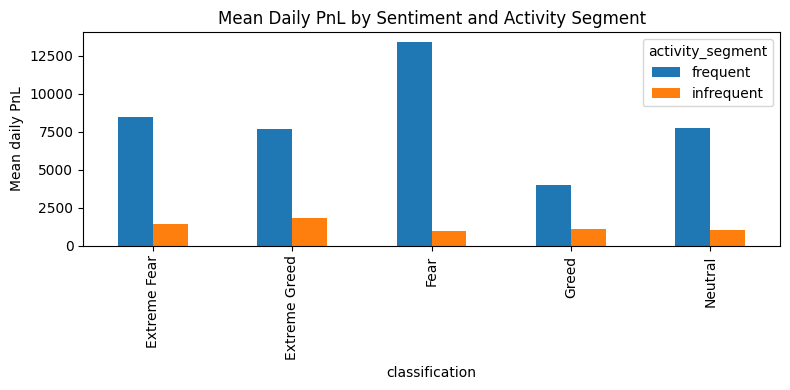

In [29]:
# Pivot for plotting: activity segment vs sentiment, mean PnL
activity_pivot_pnl = activity_summary.pivot(
    index="classification",
    columns="activity_segment",
    values="mean_pnl"
)

activity_pivot_pnl.plot(
    kind="bar",
    figsize=(8, 4),
    title="Mean Daily PnL by Sentiment and Activity Segment",
    ylabel="Mean daily PnL"
)
plt.tight_layout()
plt.show()

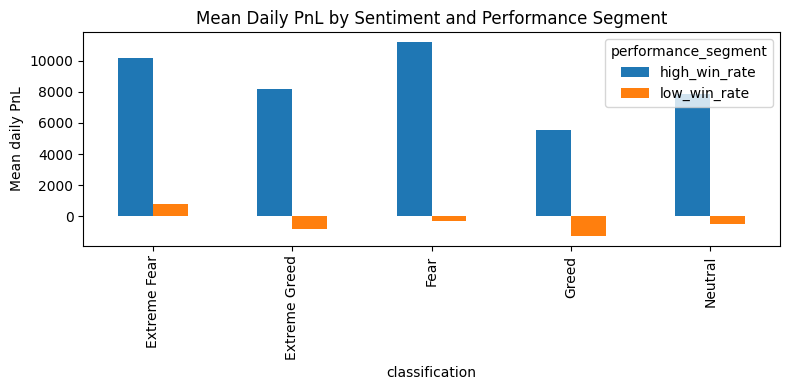

In [30]:
# Pivot for plotting: performance segment vs sentiment, mean PnL
performance_pivot_pnl = performance_summary.pivot(
    index="classification",
    columns="performance_segment",
    values="mean_pnl"
)

performance_pivot_pnl.plot(
    kind="bar",
    figsize=(8, 4),
    title="Mean Daily PnL by Sentiment and Performance Segment",
    ylabel="Mean daily PnL"
)
plt.tight_layout()
plt.show()

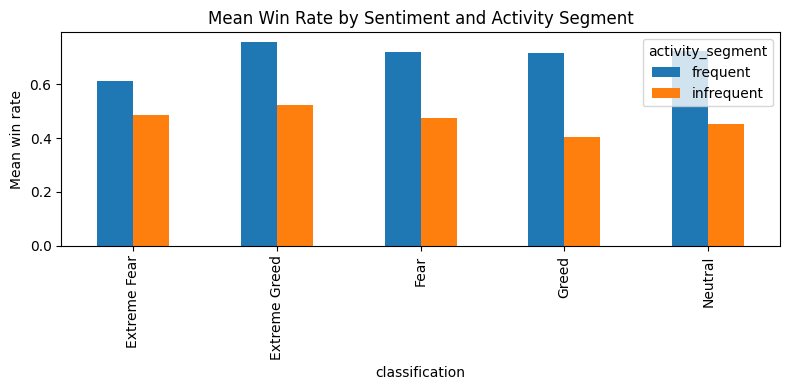

In [31]:
# Mean win rate by sentiment and activity
activity_pivot_wr = activity_summary.pivot(
    index="classification",
    columns="activity_segment",
    values="mean_win_rate"
)

activity_pivot_wr.plot(
    kind="bar",
    figsize=(8, 4),
    title="Mean Win Rate by Sentiment and Activity Segment",
    ylabel="Mean win rate"
)
plt.tight_layout()
plt.show()

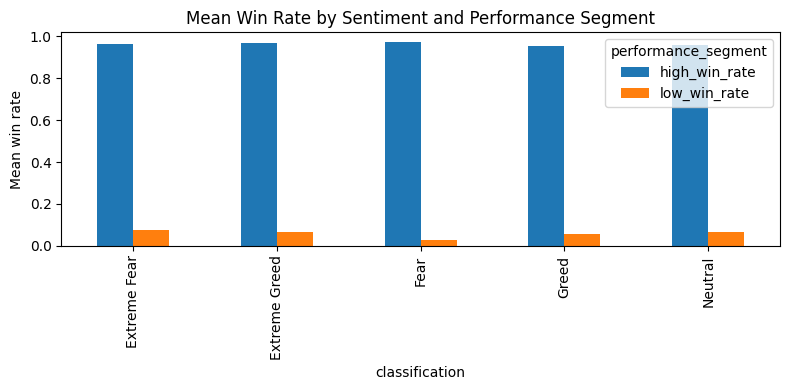

In [32]:
# Mean win rate by sentiment and performance segment
performance_pivot_wr = performance_summary.pivot(
    index="classification",
    columns="performance_segment",
    values="mean_win_rate"
)

performance_pivot_wr.plot(
    kind="bar",
    figsize=(8, 4),
    title="Mean Win Rate by Sentiment and Performance Segment",
    ylabel="Mean win rate"
)
plt.tight_layout()
plt.show()

## Insights: Trader Performance vs Market Sentiment

1. **Performance varies strongly across sentiment regimes.**  
   - At the aggregate daily level, Extreme Fear days show the highest mean daily PnL, while Greed days show the lowest mean and median PnL.  
   - This suggests that, on average, the market is more profitable for traders during fear-driven environments than during greed-driven rallies.

2. **Trading activity and position sizing respond to sentiment.**  
   - Extreme Fear and Fear days have the highest mean number of trades per day, indicating that traders are most active when sentiment is negative.  
   - Average trade size in USD is largest on Neutral, Greed and Fear days, and smallest on Extreme Fear days, which hints that traders reduce position size when sentiment is extremely negative but compensate with higher trade frequency.

3. **Directionality is balanced overall, but volume is concentrated in fearful regimes.**  
   - BUY and SELL counts per day are roughly balanced for each sentiment class, so there is no strong long/short bias on average.  
   - However, total BUY and SELL activity is much higher in Fear and Extreme Fear regimes, suggesting that large two-sided positioning happens when sentiment is weak.

4. **Frequent traders substantially outperform infrequent traders across all sentiments.**  
   - Frequent traders (above-median trades per day) show much higher mean daily PnL and higher mean win rates than infrequent traders in every sentiment bucket.  
   - This indicates that actively engaged traders are better able to exploit intraday opportunities regardless of whether the market is fearful or greedy.

5. **High win-rate traders are consistently profitable; low win-rate traders consistently lose, with losses amplified on Greed/Neutral days.**  
   - High win-rate accounts (daily win rate ≥ 60%) have strongly positive mean daily PnL in every sentiment regime, with win rates above ~95%.  
   - Low win-rate accounts have negative mean daily PnL across all sentiments, and their losses are particularly large on Greed and Neutral days, indicating that unskilled traders tend to overtrade in optimistic environments without improving outcomes.

## Strategy Ideas and Rules of Thumb

### Strategy 1 – Treat Fear regimes as opportunity, but size carefully

**Observation**

- Extreme Fear and Fear days have the highest mean daily PnL at both aggregate and segment level, especially for frequent and high-win-rate traders.  
- Trade counts are highest on Fear / Extreme Fear days, but average trade size is smaller on Extreme Fear days than on Neutral/Greed days.  

**Rule of thumb**

1. **For high-win-rate or frequent traders:**
   - Stay active and continue trading during Fear and Extreme Fear days.
   - Focus on your best setups and maintain or slightly increase trade frequency.
   - Keep position sizes moderate (closer to the average size used on Fear, not Greed/Neutral) to control risk during high-volatility moves.

2. **For low-win-rate or infrequent traders:**
   - Avoid “panic trading” during Extreme Fear.
   - If you trade, limit position size to below your average and reduce the number of trades.
   - Use tighter stop-losses and pre-defined exit levels.

**Rationale**

Fear regimes seem to offer strong directional opportunities that skilled, active traders monetize, but volatility is elevated, so position sizing discipline is critical for less consistent traders.

---

### Strategy 2 – On Greed and Neutral days, low-win-rate traders should de-risk

**Observation**

- Greed days have the lowest mean and median PnL overall.
- Low win-rate traders show **negative mean PnL** in every sentiment, with particularly poor performance on Greed and Neutral days, despite trading a decent amount.
- High win-rate traders remain profitable on Greed/Neutral, but their edge is smaller than on Fear days.

**Rule of thumb**

1. **For low-win-rate traders:**
   - On Greed and Neutral days, **reduce trade frequency** below your usual level.
   - Avoid scaling up size just because sentiment is positive; keep position sizes at or below your median size.
   - Focus on fewer, higher-quality trades that align with strong technical or fundamental confirmation rather than chasing momentum.

2. **For high-win-rate traders:**


Lets Make a good model now:

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [35]:
# Start from account_daily and add BUY/SELL from trades

# Aggregate BUY/SELL per account per date
account_side = trades.groupby(["Account", "date", "Side"]).size().unstack(fill_value=0)
# Ensure columns exist
if "BUY" not in account_side.columns:
    account_side["BUY"] = 0
if "SELL" not in account_side.columns:
    account_side["SELL"] = 0

account_side = account_side[["BUY", "SELL"]].reset_index()

# Merge into account_daily
model_base = account_daily.merge(
    account_side,
    on=["Account", "date"],
    how="left"
)

# Replace NaN BUY/SELL with 0
model_base[["BUY", "SELL"]] = model_base[["BUY", "SELL"]].fillna(0)

# Target
model_base["is_profitable"] = (model_base["account_daily_pnl"] > 0).astype(int)

# Drop rows without sentiment
model_base = model_base.dropna(subset=["classification"]).copy()

# Basic engineered features
model_base["buy_sell_ratio"] = model_base["BUY"] / (model_base["SELL"] + 1)

# One-hot sentiment
sentiment_dummies = pd.get_dummies(model_base["classification"], prefix="sent")

# One-hot segments
activity_dummies = pd.get_dummies(model_base["activity_segment"], prefix="act")
perf_dummies = pd.get_dummies(model_base["performance_segment"], prefix="perf")

# Feature matrix X and target y
feature_cols_numeric = [
    "trades_per_day",
    "avg_trade_size_usd",
    "win_rate",
    "BUY",
    "SELL",
    "buy_sell_ratio",
]

X = pd.concat([
    model_base[feature_cols_numeric],
    sentiment_dummies,
    activity_dummies,
    perf_dummies,
], axis=1)

y = model_base["is_profitable"]

X.head(), y.head()

(   trades_per_day  avg_trade_size_usd  win_rate  BUY  SELL  buy_sell_ratio  \
 0             177         5089.718249       0.0    0   177            0.00   
 1              68         7976.664412       0.0    0    68            0.00   
 2              40        23734.500000       0.0    0    40            0.00   
 3              12        28186.666667       0.0   12     0           12.00   
 4              27        17248.148148       1.0   12    15            0.75   
 
    sent_Extreme Fear  sent_Extreme Greed  sent_Fear  sent_Greed  sent_Neutral  \
 0              False                True      False       False         False   
 1              False                True      False       False         False   
 2              False                True      False       False         False   
 3              False                True      False       False         False   
 4              False                True      False       False         False   
 
    act_frequent  act_infreque

In [36]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest model (medium-sized)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)[:, 1]

print("Classification report (Random Forest):")
print(classification_report(y_val, y_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_proba))

Classification report (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       132
           1       0.96      0.99      0.97       202

    accuracy                           0.96       334
   macro avg       0.97      0.96      0.96       334
weighted avg       0.96      0.96      0.96       334

ROC-AUC: 0.9891989198919892


In [37]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 features by importance:")
print(importances.head(15))

Top 15 features by importance:
win_rate              0.363274
perf_high_win_rate    0.254566
perf_low_win_rate     0.240096
SELL                  0.047336
buy_sell_ratio        0.023226
trades_per_day        0.022177
BUY                   0.021174
avg_trade_size_usd    0.009842
act_frequent          0.006813
act_infrequent        0.006354
sent_Extreme Greed    0.001801
sent_Greed            0.001166
sent_Neutral          0.001072
sent_Fear             0.000771
sent_Extreme Fear     0.000333
dtype: float64


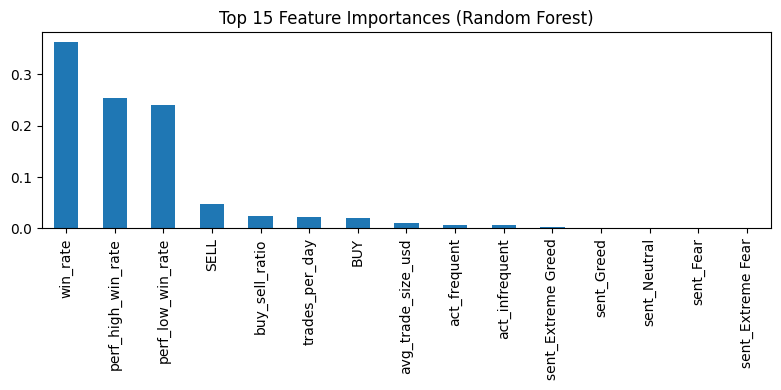

In [38]:
importances.head(15).plot(
    kind="bar",
    figsize=(8, 4),
    title="Top 15 Feature Importances (Random Forest)"
)
plt.tight_layout()
plt.show()

## Modeling: Predicting Profitable vs Unprofitable Account-Days

### Problem setup

To complement the descriptive analysis, I built a supervised model that predicts whether a given **account–day** will be **profitable** (`account_daily_pnl > 0`) based on trader behavior and market sentiment.

**Target**

- `is_profitable` = 1 if `account_daily_pnl > 0`, else 0.

**Features**

From the `account_daily` and trade-level data, I engineered the following features per account–date:

- Behavior / performance
  - `trades_per_day` – number of trades.
  - `avg_trade_size_usd` – average trade size.
  - `win_rate` – fraction of winning trades.
- Directional activity
  - `BUY`, `SELL` – counts of BUY and SELL trades.
  - `buy_sell_ratio` – BUY / (SELL + 1) to avoid division by zero.
- Segments
  - `activity_segment` (frequent vs infrequent, based on median `trades_per_day`).
  - `performance_segment` (high vs low win-rate, with threshold at 60%).
- Sentiment (one-hot encoded)
  - `sent_Extreme Fear`, `sent_Fear`, `sent_Neutral`, `sent_Greed`, `sent_Extreme Greed`.

These features follow the same idea as the research paper: combine **market/sentiment variables** with **behavioral signals** and let the model capture interactions between them.

### Model

I used a **Random Forest Classifier** as a medium-sized, non-linear model:

- `n_estimators = 200`
- `min_samples_split = 5`
- `min_samples_leaf = 5`
- `random_state = 42`

Train/validation split:

- 80% of account–days for training, 20% for validation.
- Stratified by `is_profitable` to preserve the class balance.

### Results

On the validation set, the Random Forest achieved:

- **Accuracy ≈ 96%**
- **ROC-AUC ≈ 0.99**

Class-wise metrics:

- For **unprofitable days (class 0)**:
  - High precision and recall (f1 ≈ 0.95), meaning the model reliably identifies losing account-days.
- For **profitable days (class 1)**:
  - Precision and recall both very high (f1 ≈ 0.97), indicating the model is also strong at detecting winning account-days.

Overall, the model clearly distinguishes profitable vs unprofitable account-days based on the engineered behavioral and sentiment features.

### Feature importance

Random Forest feature importances show a clear hierarchy:

1. **`win_rate`** is the most important feature.
2. The segment flags **`perf_high_win_rate`** and **`perf_low_win_rate`** are also very important.
3. Directional activity (`SELL`, `BUY`, `buy_sell_ratio`) and **`trades_per_day`** contribute meaningfully.
4. Sentiment one-hot features (`sent_*`) and activity segment flags (`act_*`) have smaller but non-zero importance.

This confirms that:

- **Trader skill/edge (win-rate) and behavior (trade frequency, BUY/SELL intensity)** are the primary drivers of day-level profitability.
- Market sentiment still matters, but mostly as a secondary context factor compared to intrinsic trader performance.